# Chapter 6.7: Conversational Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the architecture of Conversational Recommendation Systems (CRS)
2. **Implement** multi-turn dialogue for preference elicitation
3. **Build** an attribute-based questioning strategy for narrowing user preferences
4. **Create** a user simulator for training and evaluating CRS
5. **Integrate** knowledge graphs into the dialogue planning process
6. **Evaluate** CRS quality beyond just recommendation accuracy

## Prerequisites

- Chapters 6.4, 6.6 (LLM foundations and ranking)
- Basic understanding of dialogue systems
- Familiarity with knowledge graphs is helpful

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part6/chapter_6.7_conversational_rec.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part6/chapter_6.7_conversational_rec.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import defaultdict
import random

np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. CRS Architecture Overview

A Conversational Recommendation System consists of:

1. **Dialogue Manager**: Decides whether to ask a question or make a recommendation
2. **Preference Model**: Tracks user preferences from dialogue history
3. **Question Generator**: Selects which attributes to ask about
4. **Recommendation Engine**: Generates recommendations based on elicited preferences

### The CRS Workflow

```
User: "I want to watch a movie tonight"
  -> System: [ASK] "What genre do you prefer?"
User: "Something thrilling"
  -> System: [ASK] "Do you prefer recent movies or classics?"
User: "Recent ones"
  -> System: [RECOMMEND] "Based on your preferences, I suggest..."
```

> **💡 Concept:** The key challenge in CRS is the **ask vs recommend** decision. Asking too many questions annoys users; recommending too early leads to poor results. The system must balance exploration (asking) and exploitation (recommending).

In [2]:
# Define the item catalog with attributes
attributes = {
    'genre': ['Action', 'Comedy', 'Drama', 'Sci-Fi', 'Romance', 'Thriller', 'Horror'],
    'era': ['Classic', 'Modern', 'Recent'],
    'mood': ['Light', 'Intense', 'Emotional', 'Cerebral'],
    'length': ['Short', 'Medium', 'Long'],
    'rating': ['PG', 'PG-13', 'R']
}

n_items = 200
item_catalog = []
for i in range(n_items):
    item = {'id': i, 'name': f'Movie_{i}'}
    for attr_name, attr_values in attributes.items():
        item[attr_name] = random.choice(attr_values)
    item['quality'] = round(random.uniform(3.0, 5.0), 1)
    item_catalog.append(item)

# Build attribute index for fast lookup
attr_item_index = defaultdict(lambda: defaultdict(set))
for item in item_catalog:
    for attr_name in attributes:
        attr_item_index[attr_name][item[attr_name]].add(item['id'])

print(f'Catalog: {n_items} items with {len(attributes)} attribute types')
print(f'Sample item: {item_catalog[0]}')
print(f'\nAttribute stats:')
for attr_name, attr_values in attributes.items():
    counts = [len(attr_item_index[attr_name][v]) for v in attr_values]
    print(f'  {attr_name}: {dict(zip(attr_values, counts))}')

Catalog: 200 items with 5 attribute types
Sample item: {'id': 0, 'name': 'Movie_0', 'genre': 'Thriller', 'era': 'Classic', 'mood': 'Light', 'length': 'Long', 'rating': 'PG-13', 'quality': 3.5}

Attribute stats:
  genre: {'Action': 26, 'Comedy': 22, 'Drama': 34, 'Sci-Fi': 34, 'Romance': 32, 'Thriller': 31, 'Horror': 21}
  era: {'Classic': 65, 'Modern': 65, 'Recent': 70}
  mood: {'Light': 51, 'Intense': 47, 'Emotional': 52, 'Cerebral': 50}
  length: {'Short': 72, 'Medium': 65, 'Long': 63}
  rating: {'PG': 73, 'PG-13': 67, 'R': 60}


## 2. User Simulator

A user simulator is essential for training and evaluating CRS. It models:
- Fixed preferences (target attributes)
- Response behavior (how they answer questions)
- Patience level (max number of turns)

In [3]:
class UserSimulator:
    """Simulates a user in a conversational recommendation session."""
    
    def __init__(self, item_catalog, attributes, max_patience=6):
        self.catalog = item_catalog
        self.attributes = attributes
        self.max_patience = max_patience
        self.reset()
    
    def reset(self):
        """Start a new session with random preferences."""
        # Sample target preferences
        self.preferences = {}
        # Users typically have strong preferences for 2-3 attributes
        n_strong = random.randint(2, 3)
        strong_attrs = random.sample(list(self.attributes.keys()), n_strong)
        for attr in strong_attrs:
            self.preferences[attr] = random.choice(self.attributes[attr])
        
        # Find target items matching preferences
        self.target_items = set(range(len(self.catalog)))
        for attr, value in self.preferences.items():
            matching = {item['id'] for item in self.catalog if item[attr] == value}
            self.target_items &= matching
        
        self.patience = self.max_patience
        self.turn = 0
        return self.preferences, self.target_items
    
    def respond_to_question(self, attr_name):
        """Respond to an attribute question."""
        self.turn += 1
        self.patience -= 1
        
        if attr_name in self.preferences:
            # User knows their preference
            return {
                'type': 'answer',
                'attribute': attr_name,
                'value': self.preferences[attr_name],
                'certainty': 'high'
            }
        else:
            # User is unsure — pick randomly or say "no preference"
            if random.random() < 0.3:
                return {'type': 'no_preference', 'attribute': attr_name}
            else:
                return {
                    'type': 'answer',
                    'attribute': attr_name,
                    'value': random.choice(self.attributes[attr_name]),
                    'certainty': 'low'
                }
    
    def evaluate_recommendation(self, item_ids):
        """Evaluate a set of recommended items."""
        self.turn += 1
        hits = [iid for iid in item_ids if iid in self.target_items]
        if len(hits) > 0:
            return {'type': 'accept', 'accepted_items': hits}
        else:
            self.patience -= 2  # Failed recommendations cost more patience
            return {'type': 'reject'}
    
    def is_patient(self):
        return self.patience > 0


# Test user simulator
user_sim = UserSimulator(item_catalog, attributes)
prefs, targets = user_sim.reset()
print(f'User preferences: {prefs}')
print(f'Target items: {len(targets)} items')
print(f'Sample target: {item_catalog[list(targets)[0]] if targets else "None"}')

User preferences: {'era': 'Modern', 'genre': 'Thriller', 'rating': 'PG-13'}
Target items: 5 items
Sample target: {'id': 64, 'name': 'Movie_64', 'genre': 'Thriller', 'era': 'Modern', 'mood': 'Intense', 'length': 'Long', 'rating': 'PG-13', 'quality': 4.1}


## 3. Attribute-Based Questioning Strategy

The key question: **which attribute should we ask about next?**

### Information Gain Strategy

Ask about the attribute that maximally reduces the candidate set:

$$\text{attr}^* = \arg\max_{a} H(\text{candidates}) - \mathbb{E}_{v \sim p(a)}[H(\text{candidates}|a=v)]$$

where $H$ is the entropy of the candidate distribution.

In [4]:
class QuestioningStrategy:
    """Strategies for selecting which attribute to ask about."""
    
    def __init__(self, item_catalog, attributes, attr_item_index):
        self.catalog = item_catalog
        self.attributes = attributes
        self.attr_index = attr_item_index
    
    def entropy(self, candidates):
        """Compute entropy of candidate set."""
        n = len(candidates)
        if n <= 1:
            return 0
        return np.log2(n)
    
    def information_gain(self, candidates, attr_name):
        """Compute expected information gain of asking about attr_name."""
        n = len(candidates)
        if n == 0:
            return 0
        
        current_entropy = self.entropy(candidates)
        expected_entropy = 0
        
        for value in self.attributes[attr_name]:
            matching = candidates & self.attr_index[attr_name][value]
            p = len(matching) / n
            if p > 0:
                expected_entropy += p * self.entropy(matching)
        
        return current_entropy - expected_entropy
    
    def max_info_gain(self, candidates, asked_attrs):
        """Select attribute with maximum information gain."""
        best_attr = None
        best_gain = -1
        
        for attr_name in self.attributes:
            if attr_name in asked_attrs:
                continue
            gain = self.information_gain(candidates, attr_name)
            if gain > best_gain:
                best_gain = gain
                best_attr = attr_name
        
        return best_attr, best_gain
    
    def random_strategy(self, candidates, asked_attrs):
        """Random baseline: ask a random unasked attribute."""
        available = [a for a in self.attributes if a not in asked_attrs]
        if not available:
            return None, 0
        return random.choice(available), 0
    
    def popularity_strategy(self, candidates, asked_attrs):
        """Ask about the most diverse (most evenly split) attribute."""
        best_attr = None
        best_balance = -1
        
        for attr_name in self.attributes:
            if attr_name in asked_attrs:
                continue
            counts = []
            for value in self.attributes[attr_name]:
                matching = candidates & self.attr_index[attr_name][value]
                counts.append(len(matching))
            if sum(counts) > 0:
                probs = np.array(counts) / sum(counts)
                balance = -np.sum(probs * np.log2(probs + 1e-10))  # Entropy of distribution
                if balance > best_balance:
                    best_balance = balance
                    best_attr = attr_name
        
        return best_attr, best_balance


strategy = QuestioningStrategy(item_catalog, attributes, attr_item_index)

# Demonstrate information gain
all_items = set(range(n_items))
print('Information Gain for each attribute (starting with full catalog):')
for attr in attributes:
    gain = strategy.information_gain(all_items, attr)
    print(f'  {attr:8s}: {gain:.4f} bits')

Information Gain for each attribute (starting with full catalog):
  genre   : 2.7834 bits
  era     : 1.5841 bits
  mood    : 1.9990 bits
  length  : 1.5826 bits
  rating  : 1.5804 bits


## 4. Dialogue Manager

In [5]:
class DialogueManager:
    """Manages the conversation flow for CRS."""
    
    def __init__(self, item_catalog, attributes, attr_item_index,
                 rec_threshold=10, strategy='info_gain'):
        self.catalog = item_catalog
        self.attributes = attributes
        self.attr_index = attr_item_index
        self.rec_threshold = rec_threshold  # Recommend when candidates <= threshold
        self.questioner = QuestioningStrategy(item_catalog, attributes, attr_item_index)
        self.strategy_name = strategy
        self.reset()
    
    def reset(self):
        self.candidates = set(range(len(self.catalog)))
        self.known_prefs = {}
        self.asked_attrs = set()
        self.history = []
        self.turn = 0
    
    def decide_action(self):
        """Decide: ask a question or make a recommendation."""
        if len(self.candidates) <= self.rec_threshold:
            return 'recommend'
        if len(self.asked_attrs) >= len(self.attributes):
            return 'recommend'
        return 'ask'
    
    def select_question(self):
        """Select which attribute to ask about."""
        if self.strategy_name == 'info_gain':
            attr, gain = self.questioner.max_info_gain(self.candidates, self.asked_attrs)
        elif self.strategy_name == 'random':
            attr, gain = self.questioner.random_strategy(self.candidates, self.asked_attrs)
        elif self.strategy_name == 'popularity':
            attr, gain = self.questioner.popularity_strategy(self.candidates, self.asked_attrs)
        else:
            raise ValueError(f'Unknown strategy: {self.strategy_name}')
        
        self.asked_attrs.add(attr)
        return attr
    
    def process_response(self, response):
        """Update candidates based on user response."""
        if response['type'] == 'answer':
            attr = response['attribute']
            value = response['value']
            self.known_prefs[attr] = value
            # Filter candidates
            if response.get('certainty', 'high') == 'high':
                self.candidates &= self.attr_index[attr][value]
            else:
                # Soft filter: only slightly prefer matching items
                matching = self.attr_index[attr][value]
                non_matching = self.candidates - matching
                # Keep 30% of non-matching
                keep_non = set(random.sample(list(non_matching), 
                                              max(1, int(len(non_matching) * 0.3))))
                self.candidates = matching | keep_non
        
        self.turn += 1
    
    def get_recommendations(self, n=5):
        """Return top-N recommendations from remaining candidates."""
        # Sort by quality
        candidates_list = list(self.candidates)
        candidates_list.sort(key=lambda x: self.catalog[x]['quality'], reverse=True)
        return candidates_list[:n]


def run_session(dm, user_sim, verbose=True):
    """Run a complete CRS session."""
    dm.reset()
    prefs, targets = user_sim.reset()
    
    if verbose:
        print(f'\n=== New Session ===')
        print(f'User preferences: {prefs}')
        print(f'Target items: {len(targets)}')
        print(f'Initial candidates: {len(dm.candidates)}')
    
    success = False
    n_turns = 0
    
    while user_sim.is_patient() and n_turns < 8:
        action = dm.decide_action()
        
        if action == 'ask':
            attr = dm.select_question()
            if attr is None:
                action = 'recommend'
            else:
                response = user_sim.respond_to_question(attr)
                dm.process_response(response)
                n_turns += 1
                if verbose:
                    val = response.get('value', 'N/A')
                    print(f'  Turn {n_turns}: [ASK] "{attr}?" -> "{val}" '
                          f'({len(dm.candidates)} candidates left)')
                continue
        
        if action == 'recommend':
            recs = dm.get_recommendations(5)
            result = user_sim.evaluate_recommendation(recs)
            n_turns += 1
            
            if result['type'] == 'accept':
                success = True
                if verbose:
                    print(f'  Turn {n_turns}: [REC] Accepted! '
                          f'({len(result["accepted_items"])} hits)')
                break
            else:
                if verbose:
                    print(f'  Turn {n_turns}: [REC] Rejected.')
    
    return {'success': success, 'turns': n_turns, 'candidates_left': len(dm.candidates)}


# Run a demo session
dm = DialogueManager(item_catalog, attributes, attr_item_index, rec_threshold=15, strategy='info_gain')
user_sim = UserSimulator(item_catalog, attributes)
result = run_session(dm, user_sim, verbose=True)


=== New Session ===
User preferences: {'era': 'Modern', 'mood': 'Emotional', 'rating': 'PG'}
Target items: 8
Initial candidates: 200
  Turn 1: [ASK] "genre?" -> "Action" (78 candidates left)
  Turn 2: [ASK] "mood?" -> "Emotional" (24 candidates left)
  Turn 3: [ASK] "era?" -> "Modern" (11 candidates left)
  Turn 4: [REC] Accepted! (1 hits)


## 5. Strategy Comparison

info_gain    | Success: 78.50% | Avg Turns: 5.0


random       | Success: 81.00% | Avg Turns: 5.0
popularity   | Success: 82.50% | Avg Turns: 5.1


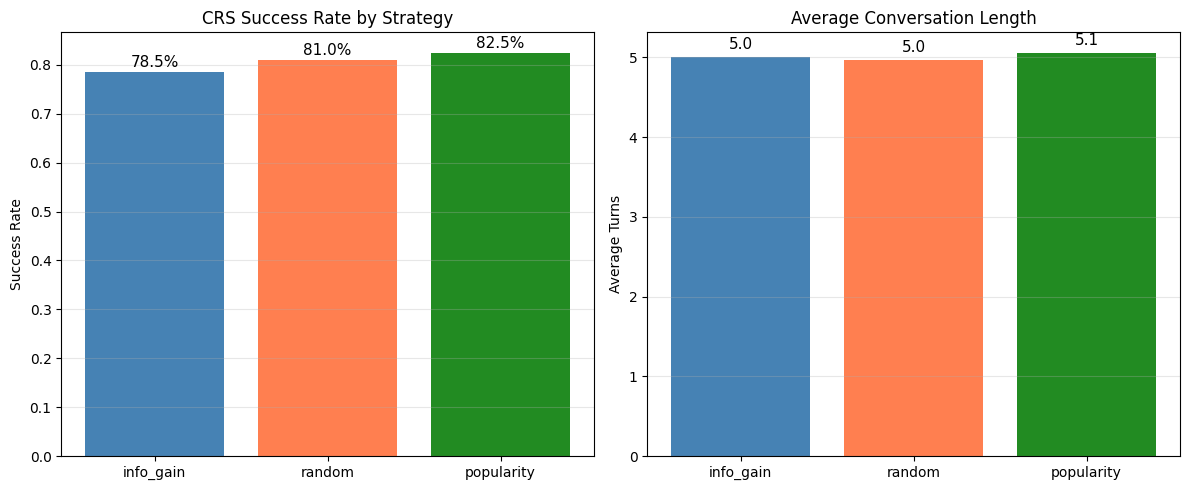

In [6]:
# Compare strategies over many sessions
strategies_to_test = ['info_gain', 'random', 'popularity']
n_sessions = 200

strategy_results = {}
for strategy_name in strategies_to_test:
    dm = DialogueManager(item_catalog, attributes, attr_item_index,
                          rec_threshold=15, strategy=strategy_name)
    successes = []
    turns_list = []
    
    for _ in range(n_sessions):
        user_sim = UserSimulator(item_catalog, attributes)
        result = run_session(dm, user_sim, verbose=False)
        successes.append(result['success'])
        turns_list.append(result['turns'])
    
    strategy_results[strategy_name] = {
        'success_rate': np.mean(successes),
        'avg_turns': np.mean(turns_list),
        'avg_turns_success': np.mean([t for t, s in zip(turns_list, successes) if s]) if any(successes) else 0
    }
    print(f'{strategy_name:12s} | Success: {np.mean(successes):.2%} | '
          f'Avg Turns: {np.mean(turns_list):.1f}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

strats = list(strategy_results.keys())
success_rates = [strategy_results[s]['success_rate'] for s in strats]
avg_turns = [strategy_results[s]['avg_turns'] for s in strats]

colors = ['steelblue', 'coral', 'forestgreen']
axes[0].bar(strats, success_rates, color=colors)
axes[0].set_ylabel('Success Rate')
axes[0].set_title('CRS Success Rate by Strategy')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(success_rates):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=11)

axes[1].bar(strats, avg_turns, color=colors)
axes[1].set_ylabel('Average Turns')
axes[1].set_title('Average Conversation Length')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(avg_turns):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 6. Knowledge Graph Integration

Knowledge graphs can enhance CRS by providing:
- **Entity relationships**: "Users who like Nolan also like Villeneuve"
- **Attribute hierarchies**: "Sci-Fi is a sub-genre of Speculative Fiction"
- **Reasoning paths**: Explain why a recommendation makes sense

> **🔑 Pro Tip:** In production CRS, knowledge graphs help generate natural-sounding questions like "Since you enjoy Nolan's films, would you be interested in Villeneuve's work?" rather than generic attribute questions.

In [7]:
class SimpleKnowledgeGraph:
    """Simplified KG for CRS."""
    
    def __init__(self):
        # Define relationships
        self.genre_similarity = {
            'Action': ['Thriller', 'Sci-Fi'],
            'Comedy': ['Romance'],
            'Drama': ['Romance', 'Thriller'],
            'Sci-Fi': ['Action', 'Thriller'],
            'Romance': ['Comedy', 'Drama'],
            'Thriller': ['Action', 'Horror', 'Drama'],
            'Horror': ['Thriller']
        }
        
        self.mood_genre = {
            'Light': ['Comedy', 'Romance'],
            'Intense': ['Action', 'Thriller', 'Horror'],
            'Emotional': ['Drama', 'Romance'],
            'Cerebral': ['Sci-Fi', 'Drama']
        }
    
    def get_related_genres(self, genre):
        return self.genre_similarity.get(genre, [])
    
    def get_genres_for_mood(self, mood):
        return self.mood_genre.get(mood, [])
    
    def expand_preferences(self, known_prefs, candidates, item_catalog):
        """Use KG to expand preference understanding."""
        expanded = dict(known_prefs)
        
        if 'genre' in known_prefs and 'mood' not in known_prefs:
            genre = known_prefs['genre']
            for mood, genres_list in self.mood_genre.items():
                if genre in genres_list:
                    expanded['inferred_mood'] = mood
                    break
        
        if 'mood' in known_prefs and 'genre' not in known_prefs:
            expanded['compatible_genres'] = self.get_genres_for_mood(known_prefs['mood'])
        
        return expanded


kg = SimpleKnowledgeGraph()

# Demo KG-enhanced preference expansion
known = {'genre': 'Sci-Fi'}
expanded = kg.expand_preferences(known, set(range(n_items)), item_catalog)
print(f'Known preferences: {known}')
print(f'Expanded preferences: {expanded}')
print(f'Related genres: {kg.get_related_genres("Sci-Fi")}')

Known preferences: {'genre': 'Sci-Fi'}
Expanded preferences: {'genre': 'Sci-Fi', 'inferred_mood': 'Cerebral'}
Related genres: ['Action', 'Thriller']


## 7. Candidate Reduction Visualization

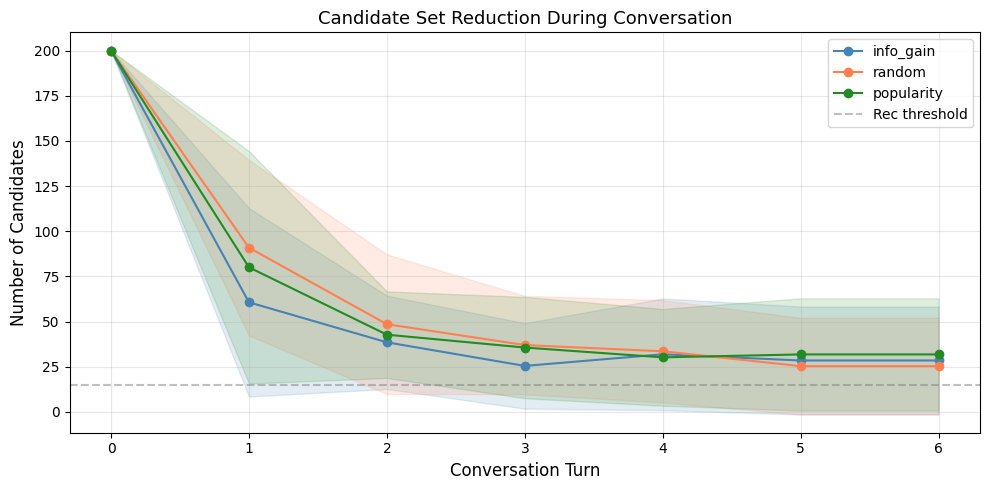

In [8]:
# Track candidate set reduction over turns
def track_candidates(strategy_name, n_trials=50):
    all_candidates_over_turns = []
    
    for _ in range(n_trials):
        dm = DialogueManager(item_catalog, attributes, attr_item_index,
                              rec_threshold=5, strategy=strategy_name)
        user_sim = UserSimulator(item_catalog, attributes, max_patience=8)
        
        dm.reset()
        prefs, targets = user_sim.reset()
        
        candidates_per_turn = [len(dm.candidates)]
        
        for turn in range(6):
            action = dm.decide_action()
            if action == 'ask':
                attr = dm.select_question()
                if attr:
                    response = user_sim.respond_to_question(attr)
                    dm.process_response(response)
                    candidates_per_turn.append(len(dm.candidates))
                else:
                    break
            else:
                break
        
        # Pad to same length
        while len(candidates_per_turn) < 7:
            candidates_per_turn.append(candidates_per_turn[-1])
        all_candidates_over_turns.append(candidates_per_turn[:7])
    
    return np.array(all_candidates_over_turns)


fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for strategy_name, color in zip(['info_gain', 'random', 'popularity'],
                                  ['steelblue', 'coral', 'forestgreen']):
    data = track_candidates(strategy_name)
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    turns = range(len(mean))
    
    ax.plot(turns, mean, '-o', color=color, label=strategy_name, markersize=6)
    ax.fill_between(turns, mean - std, mean + std, alpha=0.15, color=color)

ax.axhline(y=15, color='gray', linestyle='--', alpha=0.5, label='Rec threshold')
ax.set_xlabel('Conversation Turn', fontsize=12)
ax.set_ylabel('Number of Candidates', fontsize=12)
ax.set_title('Candidate Set Reduction During Conversation', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Build a Multi-Turn CRS with Reinforcement Learning

Train a policy network to decide when to ask vs recommend.

In [9]:
# TODO: Implement an RL-based dialogue manager
class RLDialoguePolicy(nn.Module):
    """
    TODO:
    State: [n_candidates, n_asked, n_turns, known_pref_vector]
    Actions: ['ask_genre', 'ask_era', 'ask_mood', ..., 'recommend']
    Reward: +1 for successful rec, -0.1 per turn, -1 for failed session
    
    1. Define state representation
    2. Define policy network (state -> action probabilities)
    3. Train with REINFORCE
    4. Compare with rule-based strategies
    """
    def __init__(self, state_dim, n_actions):
        super().__init__()
        # TODO: Implement
        pass
    
    def forward(self, state):
        # TODO: Implement
        pass

### 🏋️ Exercise 2: Implement User Patience Modeling

Model user patience dynamically based on the quality of questions.

In [10]:
# TODO: Dynamic patience model
# 1. Patience increases when the system asks relevant questions
#    (questions about attributes the user cares about)
# 2. Patience decreases when questions seem irrelevant
# 3. Patience drops sharply on bad recommendations
# 4. Implement an enhanced UserSimulator with dynamic patience
# 5. Show that info_gain strategy maintains patience better

### 🏋️ Exercise 3: Conversational Explanation Generation

Add explanation capability to the CRS using the knowledge graph.

In [11]:
# TODO: Implement explanation generation
# When recommending, generate explanations like:
# "Since you enjoy Sci-Fi movies and prefer cerebral films,
#  Movie_42 would be a great fit because it combines both."
#
# 1. Use known_prefs from dialogue history
# 2. Use KG relationships
# 3. Template-based explanation generation
# 4. Evaluate: do explained recommendations get higher acceptance?

## Summary

| Component | Method | Key Insight |
|-----------|--------|------------|
| **Question Selection** | Information Gain | Ask what maximally reduces uncertainty |
| **Dialogue Management** | Rule-based / RL | Balance ask vs recommend decisions |
| **User Simulation** | Preference + patience | Essential for offline evaluation |
| **KG Integration** | Preference expansion | Infer related preferences |

**Key Takeaways:**
1. Information-gain-based questioning significantly outperforms random
2. The ask/recommend decision is crucial — use the candidate set size as a signal
3. User simulation enables offline development but may not capture real behavior
4. Knowledge graphs help generate more natural and informative conversations
5. Patience modeling is critical — users leave if questions feel irrelevant